In [1]:
#金融数据

In [3]:
import quandl
import pandas_datareader.data as web
symbol = 'WIKI/AAPL'
df = quandl.get(symbol,start_date='2015-01-01', end_date='2015-09-05')

In [8]:
import pandas as pd
import tia.bbg.datamgr as dm

mgr = dm.BbgDataManager()
sids = mgr['MSFT US EQUITY', 'IBM US EQUITY', 'CSCO US EQUITY']
df = sids.get_historical('PX_LAST', '1/1/2014', '11/12/2014')
print(df)

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (v3api.py, line 186)

In [26]:
import numpy as np
frame = pd.DataFrame(np.random.randn(8,4),index=pd.date_range('1/1/2000',periods=8,freq='W-WED'),columns=['Colorado','Texas','New York','Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.126896,0.899255,0.442060,1.214259
2000-01-12,1.195219,-0.407259,-1.081071,1.867149
2000-01-19,0.649123,-2.469046,0.090486,1.224695
2000-01-26,3.029792,0.361943,0.423754,0.426687
2000-02-02,0.615584,-0.901499,0.290427,0.390142
2000-02-09,0.605308,-0.075881,1.241704,0.856714
2000-02-16,-0.770563,-1.056572,1.500550,-0.280246
2000-02-23,2.359190,0.252844,-0.679100,0.437965


In [27]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,0.126896,0.899255,0.442060,1.214259
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,1.195219,-0.407259,-1.081071,1.867149
2000-01-13,NaN,NaN,NaN,NaN
2000-01-14,NaN,NaN,NaN,NaN


In [32]:
day = frame.resample('D').ffill()
day

,Colorado,Texas,New York,Ohio
2000-01-05,0.126896,0.899255,0.442060,1.214259
2000-01-06,0.126896,0.899255,0.442060,1.214259
2000-01-07,0.126896,0.899255,0.442060,1.214259
2000-01-08,0.126896,0.899255,0.442060,1.214259
2000-01-09,0.126896,0.899255,0.442060,1.214259
2000-01-10,0.126896,0.899255,0.442060,1.214259
2000-01-11,0.126896,0.899255,0.442060,1.214259
2000-01-12,1.195219,-0.407259,-1.081071,1.867149
2000-01-13,1.195219,-0.407259,-1.081071,1.867149
2000-01-14,1.195219,-0.407259,-1.081071,1.867149


In [33]:
ret = day.pct_change().dropna()

In [34]:
ret

,Colorado,Texas,New York,Ohio
2000-01-06,0.000000,0.000000,0.000000,0.000000
2000-01-07,0.000000,0.000000,0.000000,0.000000
2000-01-08,0.000000,0.000000,0.000000,0.000000
2000-01-09,0.000000,0.000000,0.000000,0.000000
2000-01-10,0.000000,0.000000,0.000000,0.000000
2000-01-11,0.000000,0.000000,0.000000,0.000000
2000-01-12,8.418859,-1.452885,-3.445528,0.537686
2000-01-13,0.000000,0.000000,0.000000,0.000000
2000-01-14,0.000000,0.000000,0.000000,0.000000
2000-01-15,0.000000,0.000000,0.000000,0.000000


In [36]:
import statsmodels.api as sm
res = sm.tsa.seasonal_decompose(day['New York'])

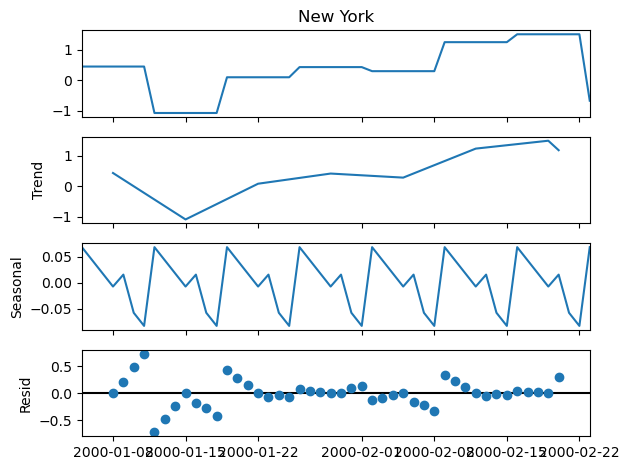

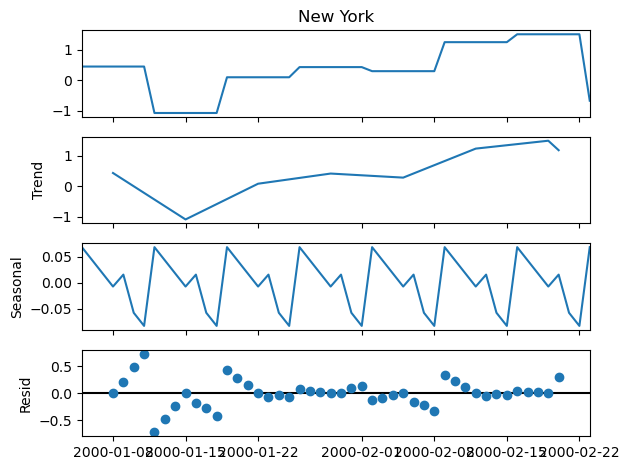

In [37]:
res.plot()